In [ ]:
# Install dependencies
!pip install datasets
# torchcodec requires a brew install ffmpeg for dependencies and then a kernel restart
!pip install torchcodec
!pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 43.4 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 38.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 38.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 24.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [torch]32m6/7 [torch]]x]s]


In [1]:
# Import libraries
from datasets import load_dataset
from datasets import concatenate_datasets
import torchcodec
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

/Users/timleong/guidepost/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = load_dataset("edinburghcstr/ami", "ihm")

In [ ]:
raw_df = concatenate_datasets([ds[s] for s in ds.keys()]).to_pandas()

In [ ]:
cols = ["meeting_id", "meeting_duration"]
raw_df["speaker_duration"] = raw_df["end_time"] - raw_df["begin_time"]
meeting_duration_df = raw_df.groupby("meeting_id")["speaker_duration"].sum().reset_index()
meeting_duration_df.columns = cols
meeting_duration_df
df = raw_df.merge(meeting_duration_df, left_on="meeting_id", right_on="meeting_id", how="left")
df.head()

,meeting_id,audio_id,text,audio,begin_time,end_time,microphone_id,speaker_id,speaker_duration,meeting_duration
0,EN2001a,AMI_EN2001a_H04_MEO069_0330297_0330718,IF YOU IF YOU S. S. H. AND THEY HAVE THIS BIG ...,{'bytes': b'RIFF\xb2\x1c\x04\x00WAVEfmt \x12\x...,3302.969971,3307.179932,H04,MEO069,4.209961,4926.540039
1,EN2001a,AMI_EN2001a_H00_MEE068_0414915_0415078,I'VE GOTTEN MM HARDLY ANY,{'bytes': b'RIFF\xb2\x97\x01\x00WAVEfmt \x12\x...,4149.149902,4150.779785,H00,MEE068,1.629883,4926.540039
2,EN2001a,AMI_EN2001a_H03_MEE067_0319290_0319815,IT'S YEAH I MEAN THE WAVE DATA ARE OBVIOUSLY N...,{'bytes': b'RIFF\xb2 \x05\x00WAVEfmt \x12\x00\...,3192.899902,3198.149902,H03,MEE067,5.250000,4926.540039
3,EN2001a,AMI_EN2001a_H04_MEO069_0145515_0146152,YEAH IT'LL IT'LL PLAY THEM IN SOME ORDER IN WH...,{'bytes': b'RIFF\xb28\x06\x00WAVEfmt \x12\x00\...,1455.150024,1461.520020,H04,MEO069,6.369995,4926.540039
4,EN2001a,AMI_EN2001a_H03_MEE067_0478127_0478164,YEAH,{'bytes': b'RIFF\xb2\\\x00\x00WAVEfmt \x12\x00...,4781.270020,4781.640137,H03,MEE067,0.370117,4926.540039


In [ ]:
# How many meetings are there in the dataset?
df["meeting_id"].nunique()

171

In [ ]:
#How long is each meeting? The units are in minutes.
(df["meeting_duration"]/60).describe()

count    134243.000000
mean         40.293869
std          16.423542
min           4.873832
25%          31.757021
50%          37.444496
75%          46.019146
max          92.955734
Name: meeting_duration, dtype: float64

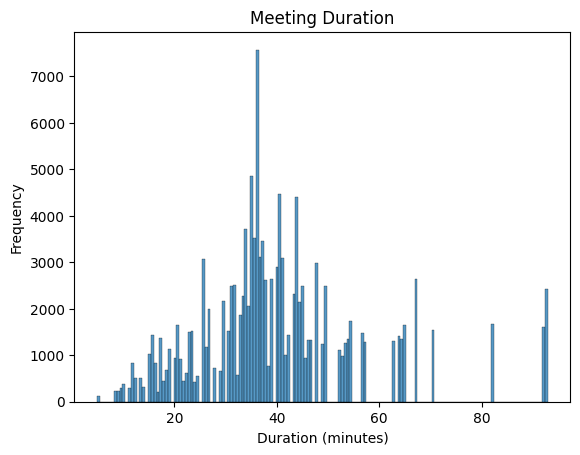

In [ ]:
sns.histplot(df["meeting_duration"]/60)
plt.title("Meeting Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")
plt.show()

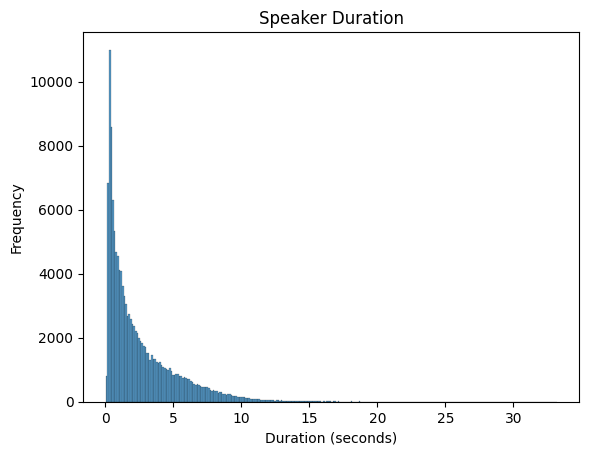

In [33]:
# How long does each speaker talk for?
sns.histplot(df["speaker_duration"])
plt.title("Speaker Duration")
plt.xlabel("Duration (seconds)")
plt.ylabel("Frequency")
plt.show()


In [49]:
speakers_per_meeting_df = (
    df.groupby("meeting_id")["speaker_id"]
      .nunique()
      .reset_index(name="num_speakers")
)

speaker_duration_df = (
    df.groupby(["meeting_id", "speaker_id"])
      .agg(
          speaker_duration=("speaker_duration", "sum"),
          meeting_duration=("meeting_duration", "mean"),
      )
      .reset_index()
).merge(speakers_per_meeting_df, left_on="meeting_id", right_on="meeting_id", how="left")

speaker_duration_df["speaker_duration_ratio"] = (
    speaker_duration_df["speaker_duration"] / speaker_duration_df["meeting_duration"]
)

speaker_duration_df.head()

,meeting_id,speaker_id,speaker_duration,meeting_duration,num_speakers,speaker_duration_ratio
0,EN2001a,FEO065,335.401123,4926.540039,5,0.068080
1,EN2001a,FEO066,659.811523,4926.540039,5,0.133930
2,EN2001a,MEE067,1021.358948,4926.540039,5,0.207318
3,EN2001a,MEE068,231.878586,4926.540039,5,0.047067
4,EN2001a,MEO069,2678.089844,4926.540039,5,0.543605


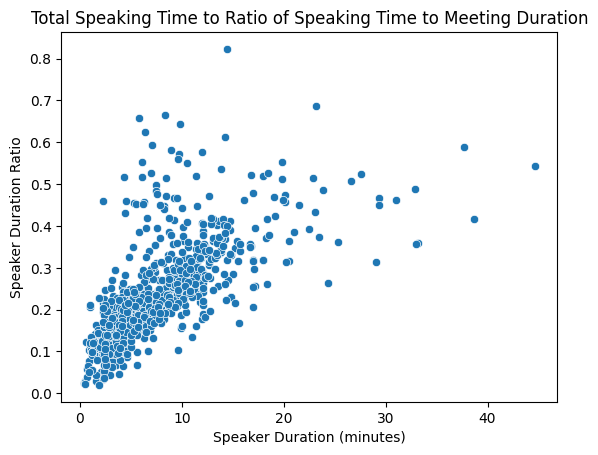

In [ ]:
# This probably gives us insight into the type of meeting. A single person dominating 
# the meeting or a group of people contributing equally. If there's lots of back and forth or not.
sns.scatterplot(
    x=speaker_duration_df["speaker_duration"]/60,
    y="speaker_duration_ratio",
    data=speaker_duration_df
)
plt.title("Total Speaking Time to Ratio of Speaking Time to Meeting Duration")
plt.xlabel("Speaker Duration (minutes)")
plt.ylabel("Speaker Duration Ratio")
plt.show()

In [58]:
speaker_duration_df["num_speakers"].value_counts()

num_speakers
4    652
5     15
3     15
Name: count, dtype: int64

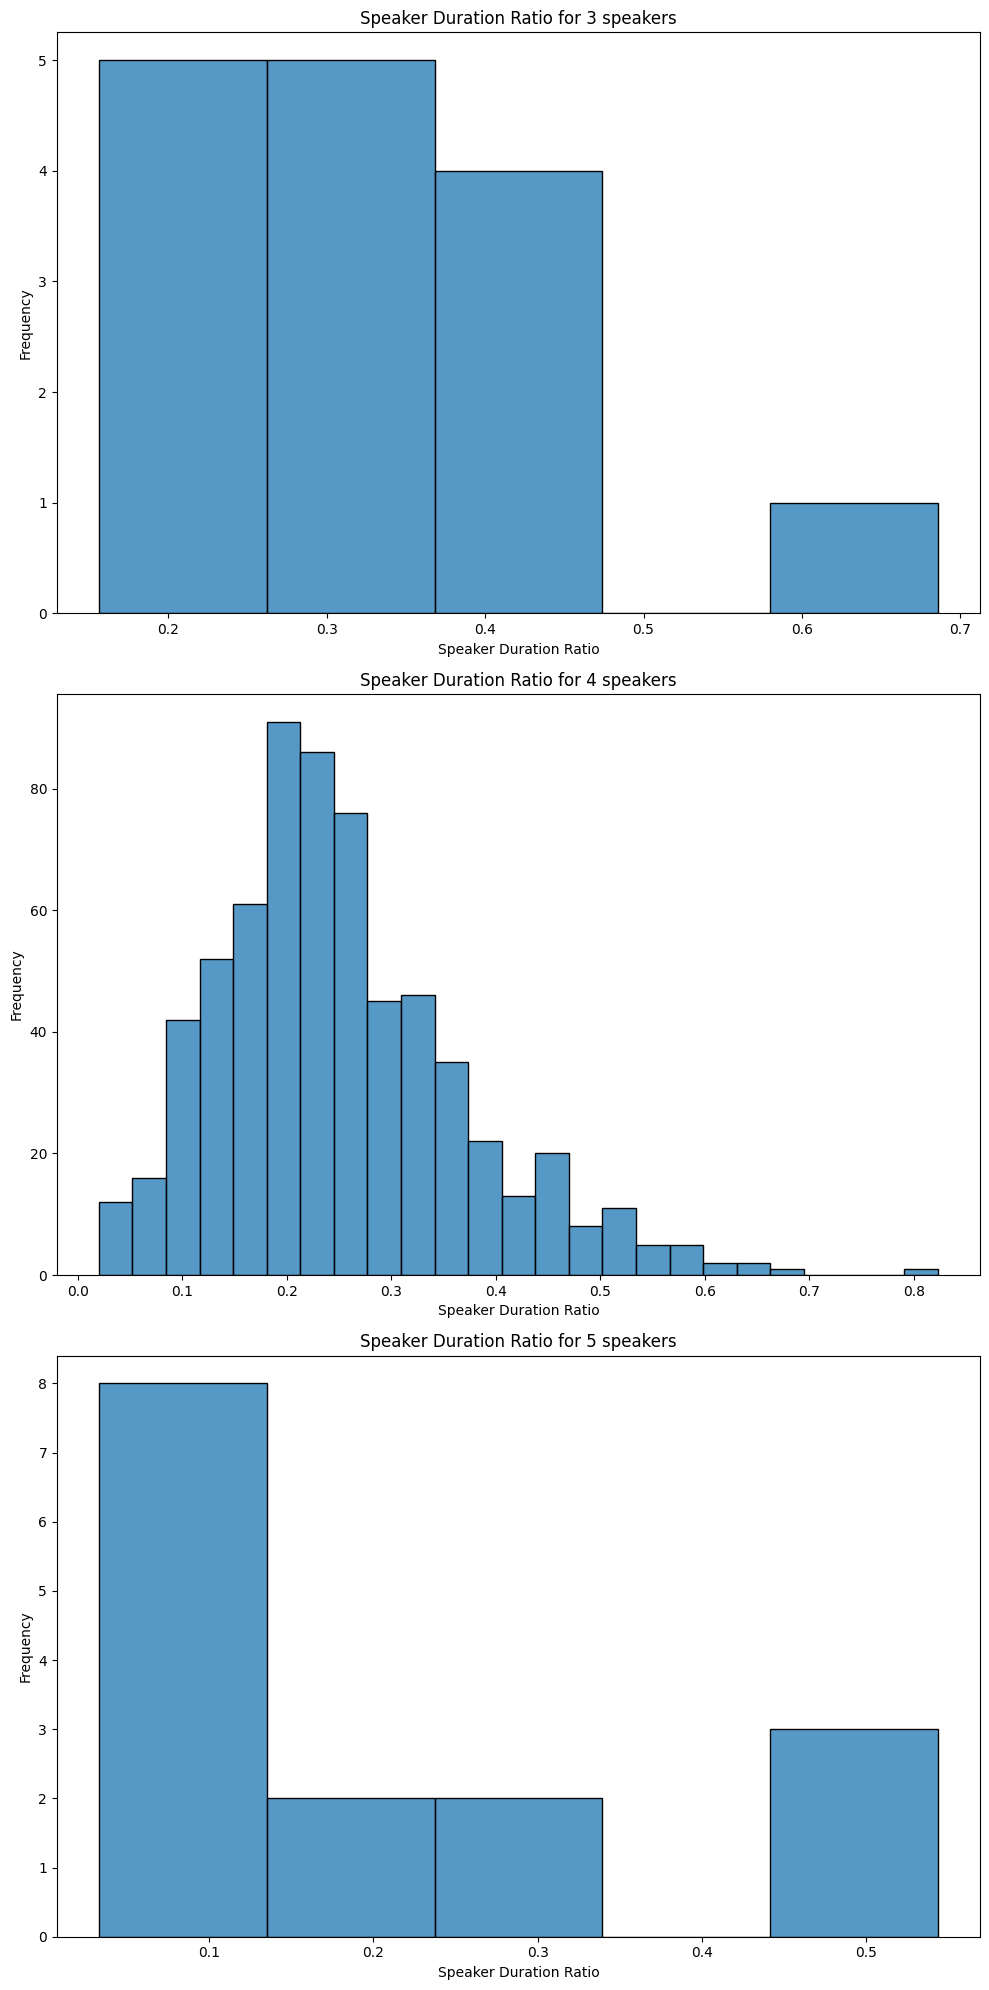

In [ ]:
# Do each of the team members contribute equally to the meeting?
num_speakers = [3,4,5]
fig, ax = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(10, 20)
    )

axes = ax.flatten()
i=0
for num in num_speakers:
    sns.histplot(
        speaker_duration_df[speaker_duration_df["num_speakers"] == num]["speaker_duration_ratio"],
        ax=axes[i],
    )
    axes[i].set_title(f"Speaker Duration Ratio for {num} speakers")
    axes[i].set_xlabel("Speaker Duration Ratio")
    axes[i].set_ylabel("Frequency")
    i += 1
plt.tight_layout()
plt.show()